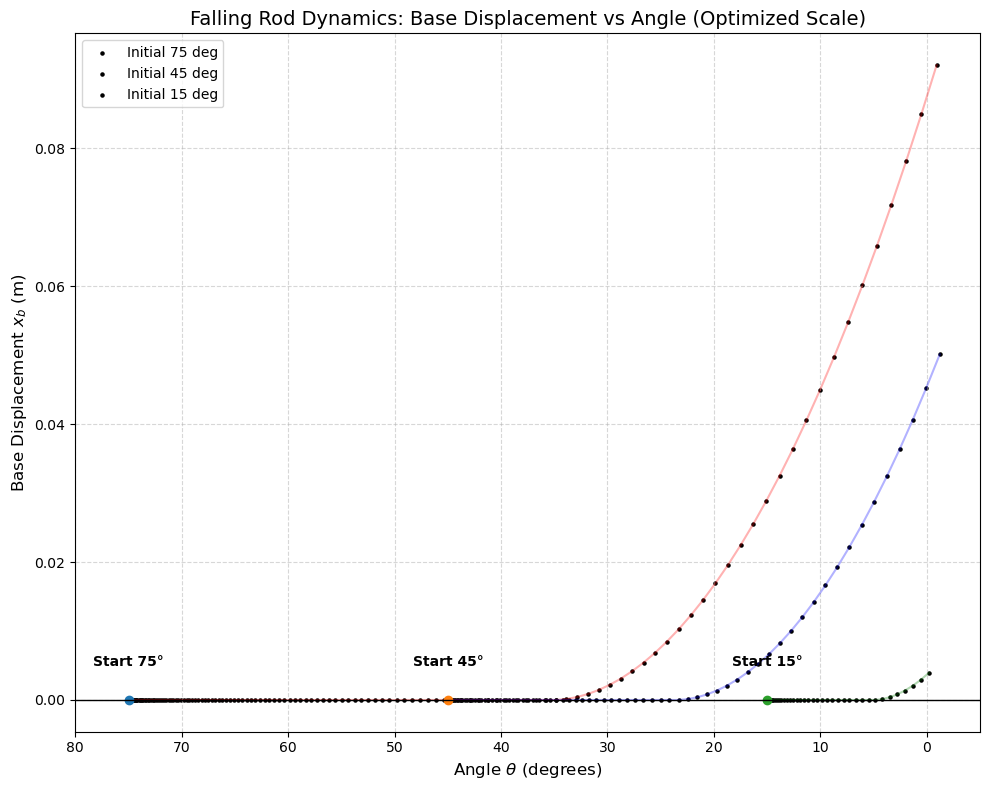

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1. 물리 상수 및 설정
G = 9.80665
L = 1.0     # 막대 길이
M = 1.0     # 막대 질량
DT = 0.005  # 시간 간격 (0.001s)
MU_S = 0.76  # 정지 마찰계수
MU_K = 0.44  # 운동 마찰계수

def simulate_falling_rod(initial_theta_deg, mu_s, mu_k):
    theta = np.radians(initial_theta_deg)
    theta0 = theta
    omega = 0.0
    x_b = 0.0
    vx_b = 0.0
    
    results = []
    slipping_started = False
    
    # 최대 2초 동안 시뮬레이션
    for i in range(int(2.0 / DT)):
        # 1. 미끄러짐 여부 판단 (논문 식 2, 3 기반)
        if not slipping_started:
            f = (M * G / 4) * (9 * np.cos(theta) * np.sin(theta) - 6 * np.sin(theta0) * np.cos(theta))
            N = (M * G / 4) * (1 + 9 * (np.sin(theta)**2) - 6 * np.sin(theta0) * np.sin(theta))
            if abs(f) > mu_s * N:
                slipping_started = True
        
        # 2. 가속도 계산 (논문 식 1, 5, 6 기반)
        if not slipping_started:
            alpha = (3.0 * G / (2.0 * L)) * np.cos(theta)
            ax_b = 0.0
        else:
            b = 1.0 / (3 * np.cos(theta) - 3 * mu_k * np.sin(theta))
            alpha = (2*G/L - omega**2 * np.sin(theta)) / (np.cos(theta) + b)
            ax_b = (omega**2 * L / 2) * np.cos(theta) - (alpha * L / 2) * (np.sin(theta) - 3 * mu_k * b)

        # 3. 상태 업데이트 (Euler Method)
        omega += alpha * DT
        theta -= omega * DT
        vx_b += ax_b * DT
        x_b += vx_b * DT
        
        results.append([np.degrees(theta), x_b])
        
        if theta <= 0:
            break
            
    return np.array(results)

# 2. 세 가지 초기 각도에 대해 시뮬레이션 실행
cases = [75, 45, 15]
colors = ['red', 'blue', 'green']
plt.figure(figsize=(10, 8))

for theta_init, col in zip(cases, colors):
    data = simulate_falling_rod(theta_init, MU_S, MU_K)
    angles = data[:, 0]
    displacements = data[:, 1]
    
    # x축: angles (각도), y축: displacements (위치)
    plt.plot(angles, displacements, color=col, alpha=0.3)
    plt.scatter(angles, displacements, color='black', s=5, label=f'Initial {theta_init} deg')
    
    # 초기 시작 지점 강조
    plt.plot(angles[0], displacements[0], 'o') 
    plt.text(angles[0], displacements[0] + 0.005, f'Start {theta_init}°', 
             fontsize=10, fontweight='bold', ha='center')

# 3. 그래프 스타일링 및 스케일 조정 (왼쪽 빈 공간 제거)
plt.axhline(y=0, color='black', linestyle='-', linewidth=1)

# x축(각도) 범위를 45도(최대 초기값)에서 0도로 타이트하게 설정하여 왼쪽 빈 공간을 당김
plt.xlim(max(cases) + 5, -5) 

plt.title('Falling Rod Dynamics: Base Displacement vs Angle (Optimized Scale)', fontsize=14)
plt.xlabel('Angle $\\theta$ (degrees)', fontsize=12)
plt.ylabel('Base Displacement $x_b$ (m)', fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

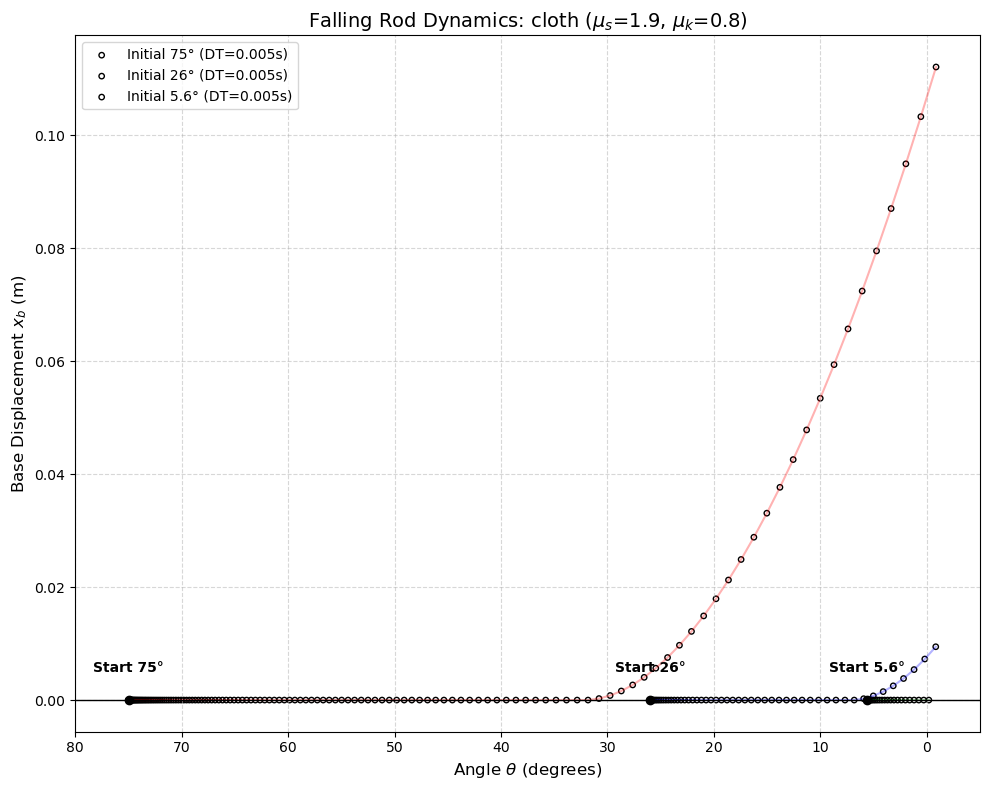

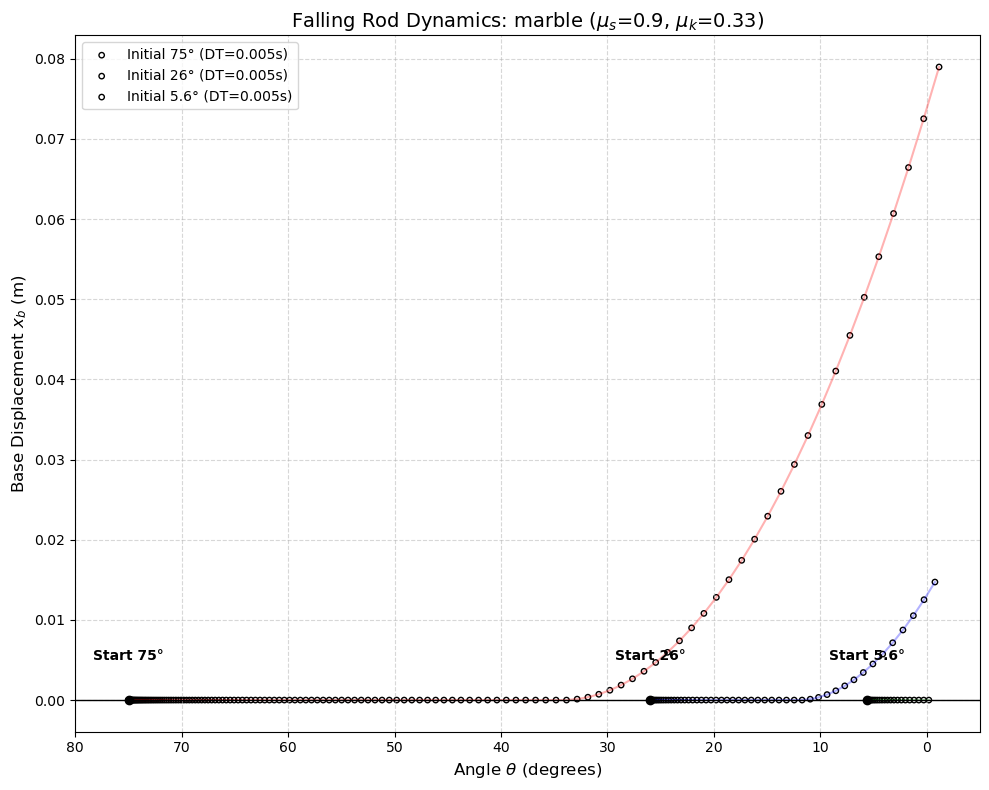

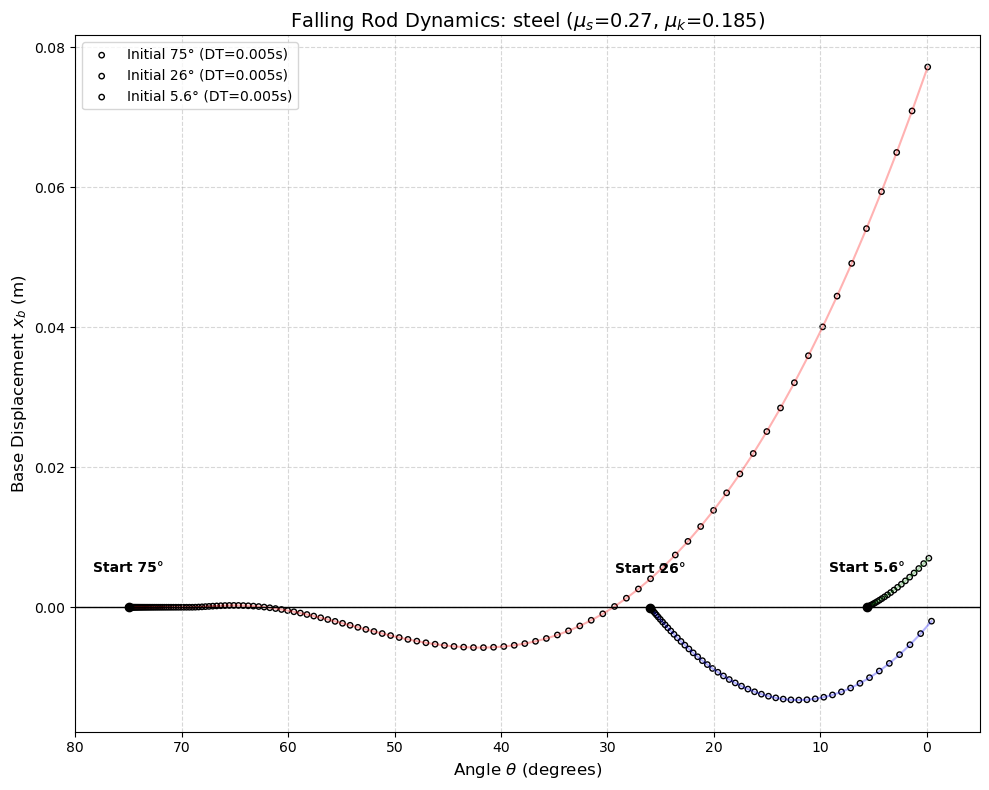

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 물리 상수 설정
G = 9.80665
L = 1.0      # 막대 길이
M = 1.0      # 막대 질량
DT = 0.005   # 시간 간격 (0.005s)

def simulate_falling_rod(initial_theta_deg, mu_s, mu_k):
    theta = np.radians(initial_theta_deg)
    theta0 = theta
    omega = 0.0
    x_b = 0.0
    vx_b = 0.0
    
    results = []
    slipping_started = False
    
    # 최대 2초 동안 시뮬레이션
    for i in range(int(2.0 / DT)):
        # 1. 미끄러짐 여부 판단 (논문 식 2, 3 기반)
        if not slipping_started:
            f = (M * G / 4) * (9 * np.cos(theta) * np.sin(theta) - 6 * np.sin(theta0) * np.cos(theta))
            N = (M * G / 4) * (1 + 9 * (np.sin(theta)**2) - 6 * np.sin(theta0) * np.sin(theta))
            if abs(f) > mu_s * N:
                slipping_started = True
        
        # 2. 가속도 계산 (논문 식 1, 5, 6 기반)
        if not slipping_started:
            alpha = (3.0 * G / (2.0 * L)) * np.cos(theta)
            ax_b = 0.0
        else:
            b = 1.0 / (3 * np.cos(theta) - 3 * mu_k * np.sin(theta))
            alpha = (2*G/L - omega**2 * np.sin(theta)) / (np.cos(theta) + b)
            ax_b = (omega**2 * L / 2) * np.cos(theta) - (alpha * L / 2) * (np.sin(theta) - 3 * mu_k * b)

        # 3. 상태 업데이트 (Euler Method)
        omega += alpha * DT
        theta -= omega * DT
        vx_b += ax_b * DT
        x_b += vx_b * DT
        
        results.append([np.degrees(theta), x_b])
        
        if theta <= 0:
            break
            
    return np.array(results)

# 2. 표면 데이터 설정 (이름, mu_s, mu_k)
surfaces = [
    {"name": "cloth", "mu_s": 1.9, "mu_k": 0.8},
    {"name": "marble", "mu_s": 0.9, "mu_k": 0.33},
    {"name": "steel", "mu_s": 0.27, "mu_k": 0.185}
]

cases = [75, 26,5.6 ]
colors = ['red', 'blue', 'green']

# 3. 표면별 루프 (총 3개의 단일 캔버스 그림 생성)
for surf in surfaces:
    # 표면 하나당 독립된 그림 창 1개 생성
    plt.figure(figsize=(10, 8))
    
    # 각도별 루프 (동일한 캔버스에 3개의 그래프를 겹쳐서 그림)
    for theta_init, col in zip(cases, colors):
        data = simulate_falling_rod(theta_init, surf['mu_s'], surf['mu_k'])
        angles = data[:, 0]
        displacements = data[:, 1]
        
        # 궤적 라인 플롯
        plt.plot(angles, displacements, color=col, alpha=0.3)
        
        # 0.005s 간격의 점 플롯 (내용물이 비어있는 검정색 실선 원)
        plt.scatter(angles, displacements, facecolors='none', edgecolors='black', 
                    s=15, marker='o', label=f'Initial {theta_init}° (DT=0.005s)')
        
        # 초기 시작 지점 강조 (검은색 채워진 점)
        plt.plot(angles[0], displacements[0], 'ko', markersize=6) 
        plt.text(angles[0], displacements[0] + 0.005, f'Start {theta_init}°', 
                 fontsize=10, fontweight='bold', ha='center')
        
    # 그래프 스타일링 및 스케일 조정 (왼쪽 빈 공간 제거)
    plt.axhline(y=0, color='black', linestyle='-', linewidth=1)
    
    # 3개 각도가 한 장에 있으므로, 가장 큰 초기각도인 75도 기준으로 왼쪽 여백 당김
    plt.xlim(max(cases) + 5, -5) 
    
    plt.title(f"Falling Rod Dynamics: {surf['name']} ($\mu_s$={surf['mu_s']}, $\mu_k$={surf['mu_k']})", fontsize=14)
    plt.xlabel('Angle $\\theta$ (degrees)', fontsize=12)
    plt.ylabel('Base Displacement $x_b$ (m)', fontsize=12)
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.legend(loc='best')
    
    plt.tight_layout()

# 모든 그림 출력
plt.show()